In [353]:
from pathlib import Path

import confnotebook

source = Path("../examples/test/bag_15062026")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")


[0] 000-591590 2024 Р±РЅ
[1] 000-591590 2025 Р±РЅ
[2] 000-591590 2026 Р±РЅ
[3] 04062001scan
[4] 1 квартал 2026
[5] 113130_Черно-бел. док-т_04062026
[6] 20260604scan150446
[7] 3 кв. 2025
[8] Scan_0034
[9] scan_20010116015111
[10] АС АО КУРГАНМАШЗАВОД
[11] АС РБ за 2025 г
[12] АС СУЭК апрель 26
[13] АСВ Лоста на 31.03.
[14] Акт Сверки РУСАЛ Ачинск
[15] Акт сверки 01012026-31032026
[16] Акт сверки 2025 от 16.04.2026 (1)
[17] Акт сверки 2026 от 16.04.2026
[18] Акт сверки взаиморасчетов № 05800004074 от 29 мая 2026 г
[19] Акт сверки взаиморасчетов № 102 от 03 июня 2026 г
[20] Акт сверки взаиморасчетов № 151 от 20 мая 2026 г без 9_10 этапа
[21] Акт сверки взаиморасчетов № 6171 от 02 июня 2026 г
[22] Акт сверки май 2026
[23] Акт сверки янв-мар 2026 (подпись К-ПМ)
[24] Акт сверки №1523 от 21.04.26 - 5f1bfca4-fde6-48ac-93cd-9266c8fa14d2
[25] Акт сверки №И--000238 от 06.04.26 РИТС
[26] Акт сверки
[27] Альфа-Металл
[28] БАЙКАЛ АКВА Акт сверки 2025-2026.05.28 от КП Крокус (002)
[29] Байкал Аква 23

In [354]:
IDX_FILE = 45
NUM_PAGE = 0

DEBUG = True

In [355]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.pipelines.build_document import DocumentBuildPipeline
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor

build_pipeline = DocumentBuildPipeline()

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=NUM_PAGE, dpi=200)

img, _ = PageOrientationPreprocessor().process(img)
ocr_results, _ = build_pipeline._run_ocr(img)

Creating model: ('PP-OCRv5_server_det', '/mnt/data/projects/rusal_recon_srv/repo/recon_vision/models/PP-OCRv5_server_det')
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', '/mnt/data/projects/rusal_recon_srv/repo/recon_vision/models/cyrillic_PP-OCRv5_mobile_rec')
2026-07-18 00:38:06.256 | DEBUG    | vision_core.preprocessor.image_orientation:process:47 - Ориентация страницы: 0° с точностью 0.9202
2026-07-18 00:38:06.268 | DEBUG    | vision_core.preprocessor.image_orientation:compute_deskew_angle:119 - Углы наклона страницы: -2.6974°
2026-07-18 00:38:06.623 | DEBUG    | vision_core.pipelines.build_document:_run_ocr:235 - OCR: распознано 128 блоков, средняя уверенность: 0.90


In [356]:
from vision_core.detector.table_detector import TableDetector

detector = TableDetector(ocr_engine=build_pipeline.ocr_engine)

_ = detector.detect_tables(img, ocr_results, NUM_PAGE)

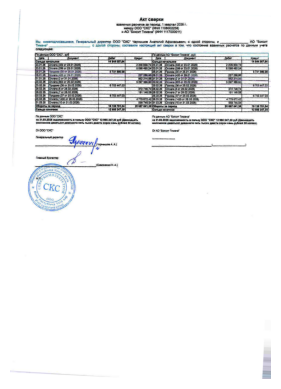

In [357]:
from matplotlib import pyplot as plt

if DEBUG:
    plt.imshow(detector._sharpness_img)
    plt.axis("off")
    plt.show()

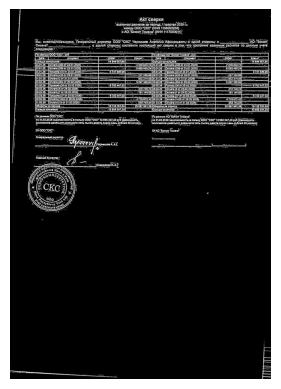

In [358]:
if DEBUG:
    plt.imshow(detector._binary_img, cmap="gray")
    plt.axis("off")
    plt.show()

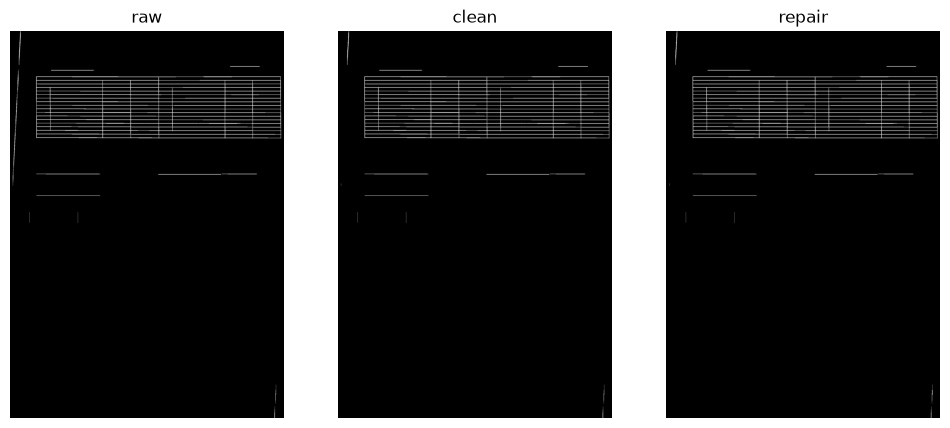

In [359]:
if DEBUG:
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))

    axes[0].imshow(detector._mask_raw_lines, cmap="gray")
    axes[0].set_title("raw")
    axes[0].axis("off")

    axes[1].imshow(detector._mask_clean_lines, cmap="gray")
    axes[1].set_title("clean")
    axes[1].axis("off")

    axes[2].imshow(detector._mask_fixed, cmap="gray")
    axes[2].set_title("repair")
    axes[2].axis("off")

    plt.show()

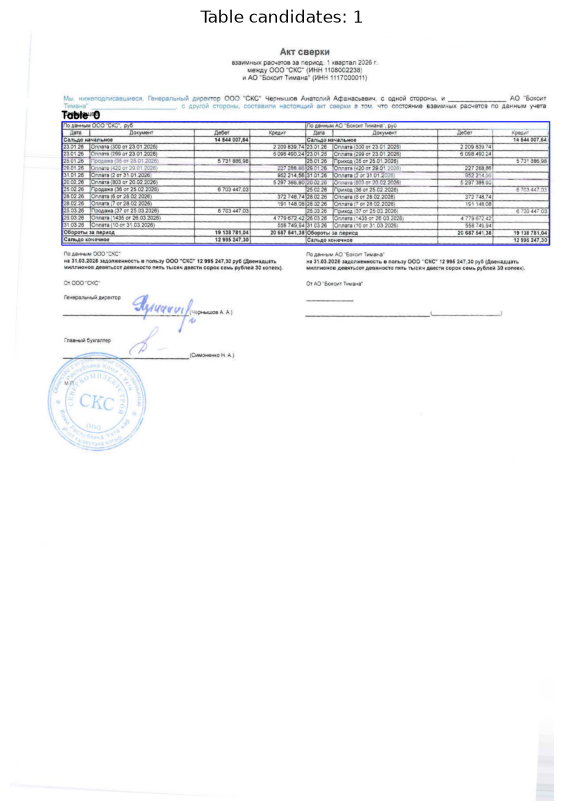

In [360]:
import cv2

table_candidates = detector._find_table_candidates(detector.ocr_bboxes)

vis = img.copy()
for i, bbox in enumerate(table_candidates):
    x, y, w, h = bbox.to_tuple()
    cv2.putText(vis, f"Table {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)
    cv2.rectangle(vis, (x, y), (w, h), (0, 0, 255), 2)
plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title(f"Table candidates: {len(table_candidates)}")
plt.axis("off")
plt.show()

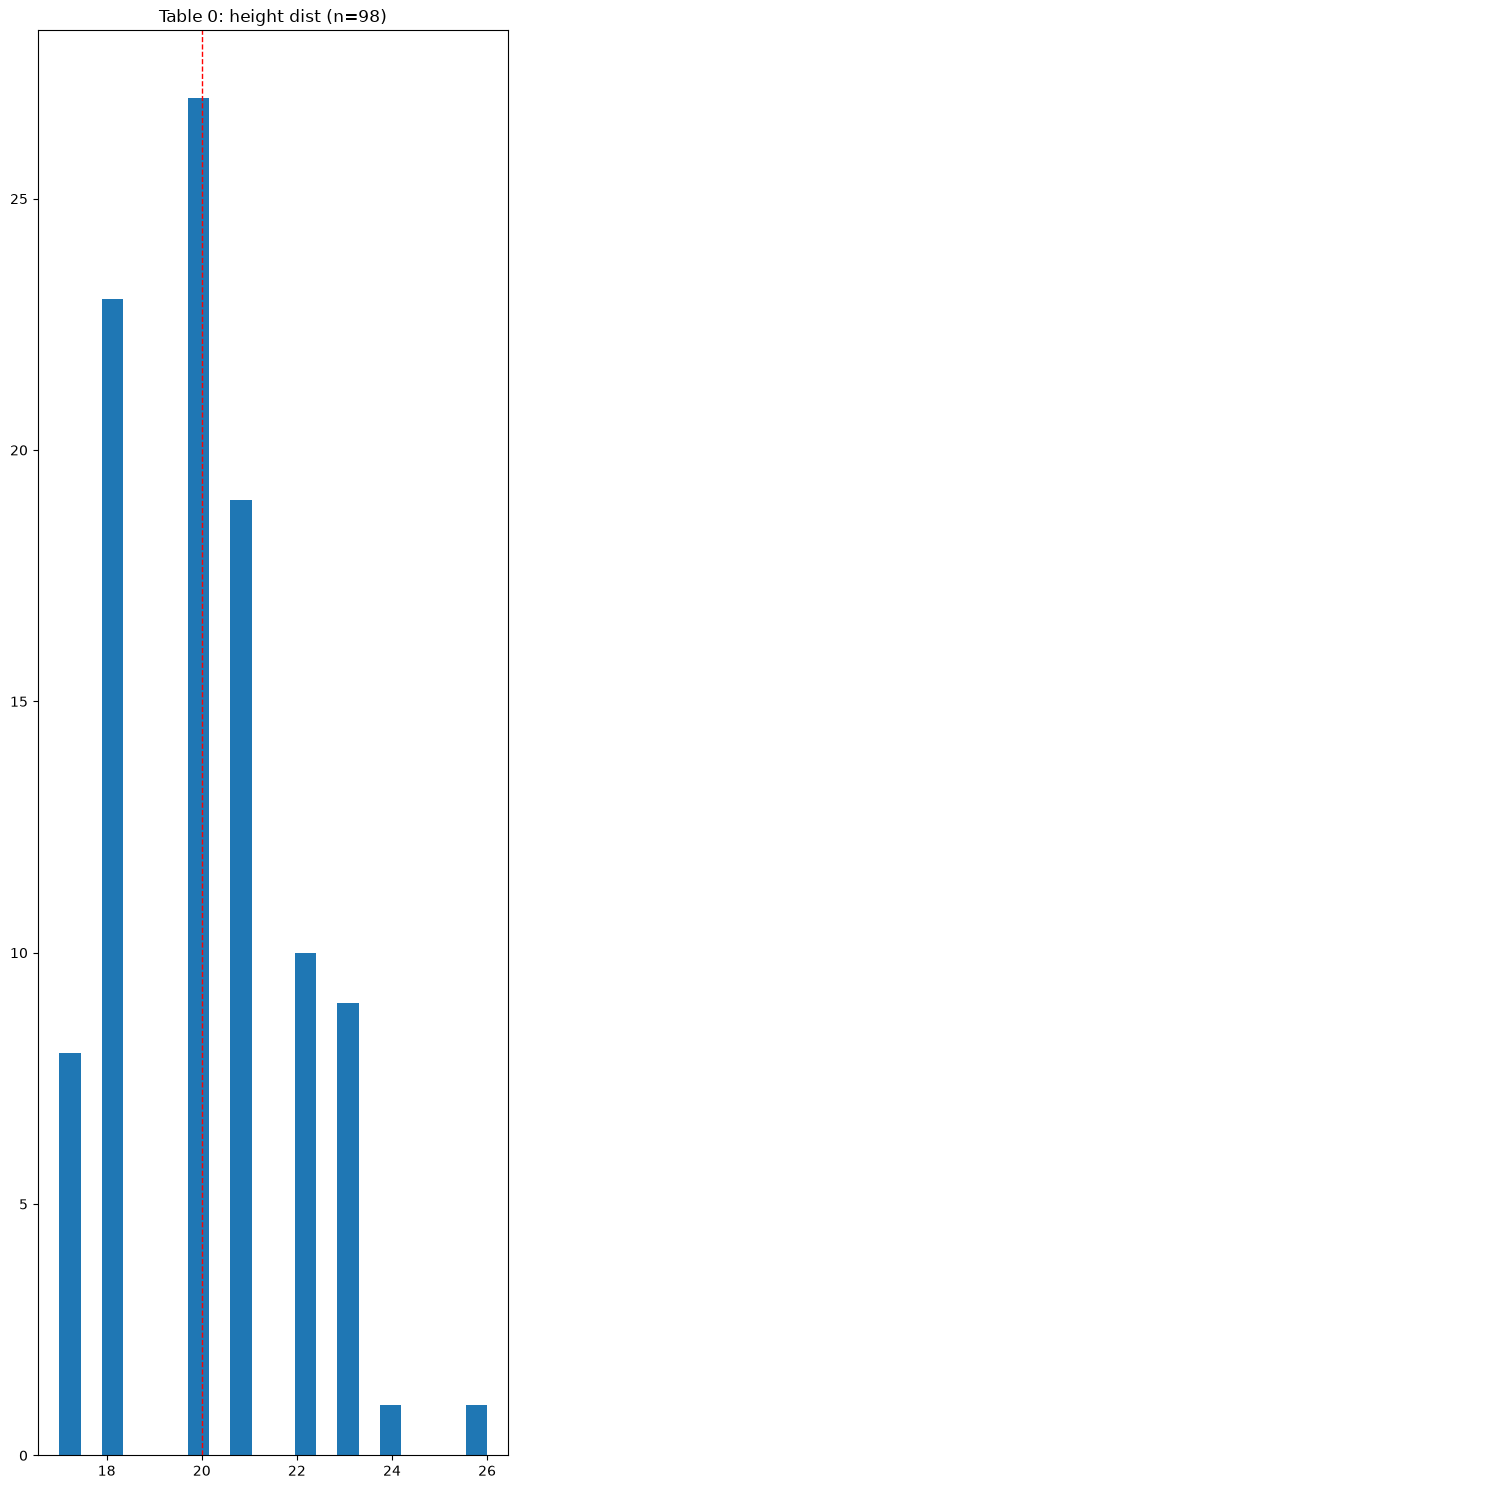

In [361]:
import numpy as np

from vision_core.detector.table_detector import overlapping_bboxes, overlapping_heights

n = len(table_candidates)
cols = 3
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 15))
axes = np.atleast_1d(axes).ravel()

list_median_heights = []

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))
    list_median_heights.append(median_height)

    ax = axes[i]
    ax.hist(heights, bins=20)
    # пунткирная линия медианы
    ax.axvline(median_height, color="r", linestyle="dashed", linewidth=1)
    ax.set_title(f"Table {i}: height dist (n={len(heights)})")

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

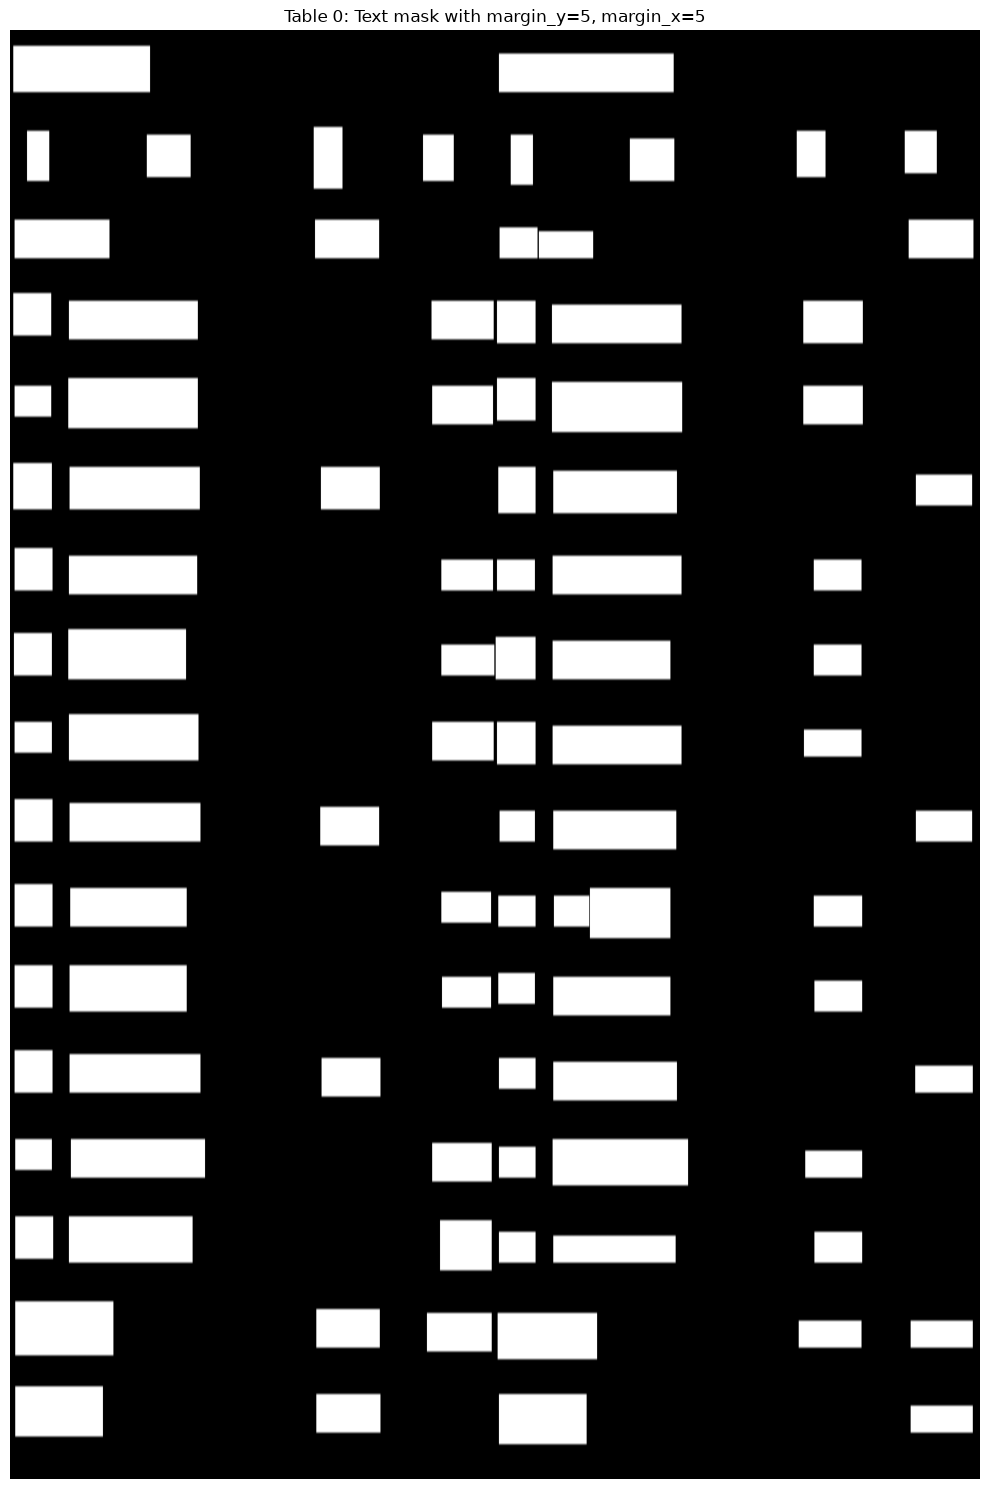

In [362]:
from vision_core.detector.table_detector import text_mask_inset

n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 15))
axes = np.atleast_1d(axes).ravel()

list_text_masks = []

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    mask = text_mask_inset(bbox, boxes, pix=5)
    list_text_masks.append(mask)

    ax = axes[i]
    ax.imshow(mask, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={5}, margin_x={5}")
    ax.axis("off")

fig.tight_layout()
plt.show()

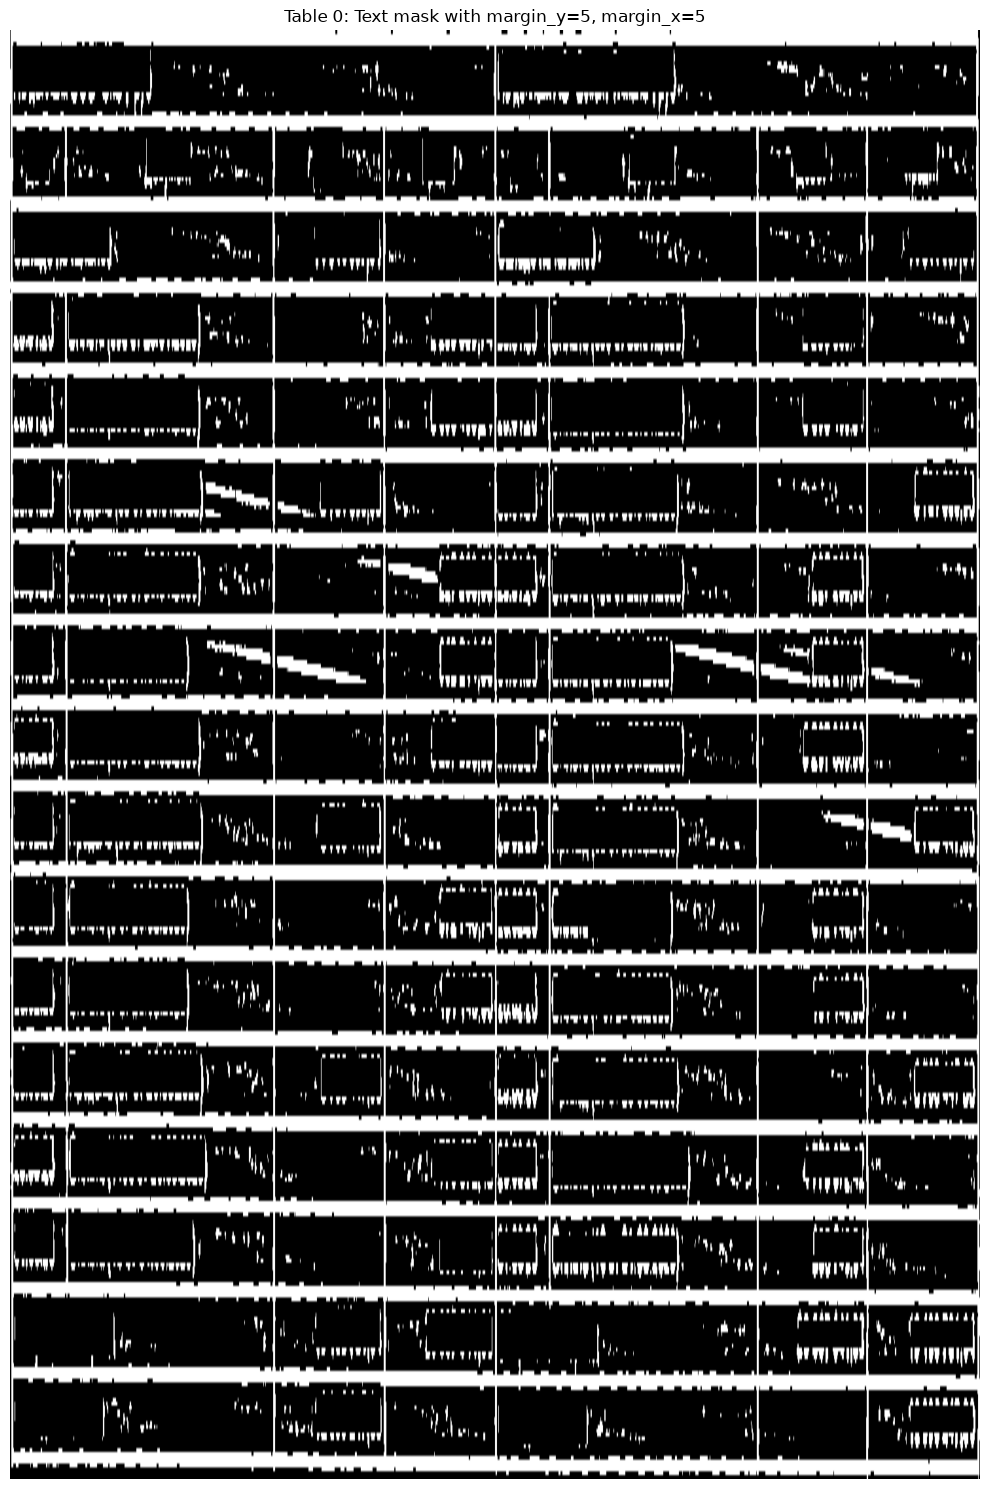

In [363]:
from vision_core.detector.table_detector import text_mask_inset
from vision_core.utils import image_utils

n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 15))
axes = np.atleast_1d(axes).ravel()

list_no_text = []

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    mask = text_mask_inset(bbox, boxes, pix=5)
    no_text = image_utils.subtract_mask(bbox.roi(detector._binary_img_clean_lines), mask)
    no_text = image_utils.get_mask(no_text, bbox.roi(detector._mask_fixed))
    list_no_text.append(no_text)

    ax = axes[i]
    ax.imshow(no_text, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={5}, margin_x={5}")
    ax.axis("off")

fig.tight_layout()
plt.show()

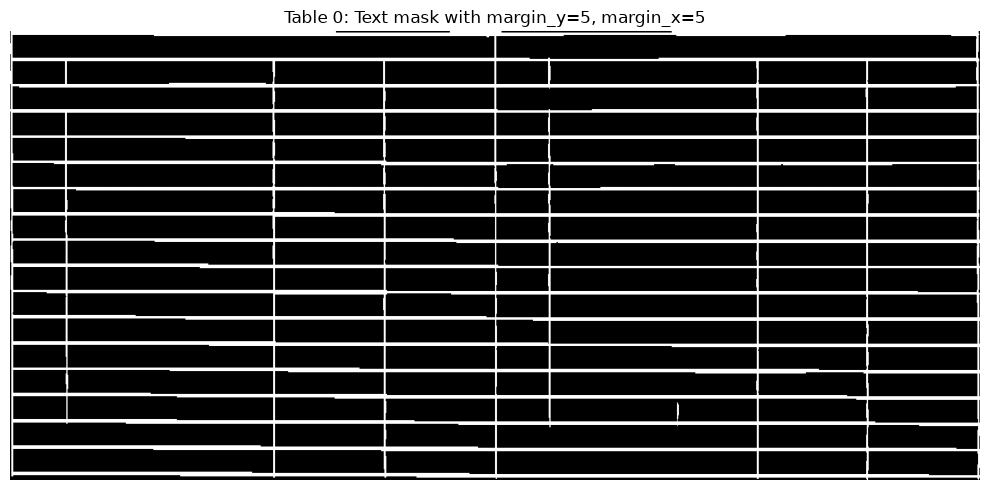

In [364]:
n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 5))
axes = np.atleast_1d(axes).ravel()


for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, _ = detector._clean_mask_table(bbox, boxes, median_height)

    ax = axes[i]
    ax.imshow(mask, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={5}, margin_x={5}")
    ax.axis("off")

fig.tight_layout()
plt.show()

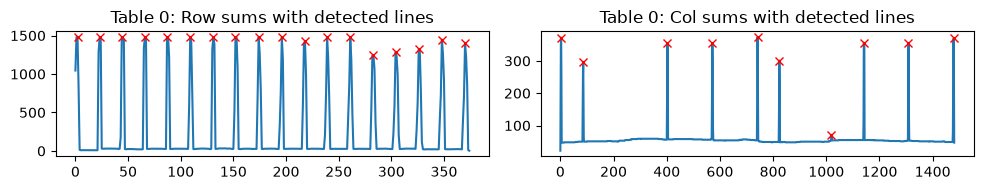

In [365]:
from vision_core.detector.table_detector import find_lines_with_edges, sum_pixel_axis

cols = 2
rows = n

fig, axes = plt.subplots(rows, cols, figsize=(10, 2 * rows))
axes = np.atleast_2d(axes)


for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, _ = detector._clean_mask_table(bbox, boxes, median_height)
    row_pix = sum_pixel_axis(mask, axis=1)
    col_pix = sum_pixel_axis(mask, axis=0)

    row_peaks = find_lines_with_edges(
        row_pix,
        distance=10,
        prominence_frac=0.2,
        edge_check_width=5,
        edge_frac=0.5,
    )

    col_peaks = find_lines_with_edges(
        col_pix,
        distance=20,
        prominence_frac=0.2,
        edge_check_width=5,
        edge_frac=0.5,
    )

    ax_rows, ax_cols = axes[i, 0], axes[i, 1]
    ax_rows.plot(row_pix)
    ax_rows.plot(row_peaks, row_pix[row_peaks], "rx")
    ax_rows.set_title(f"Table {i}: Row sums with detected lines")
    ax_cols.plot(col_pix)
    ax_cols.plot(col_peaks, col_pix[col_peaks], "rx")
    ax_cols.set_title(f"Table {i}: Col sums with detected lines")

fig.tight_layout()
plt.show()

Table 0: row_ys=18, col_xs=10


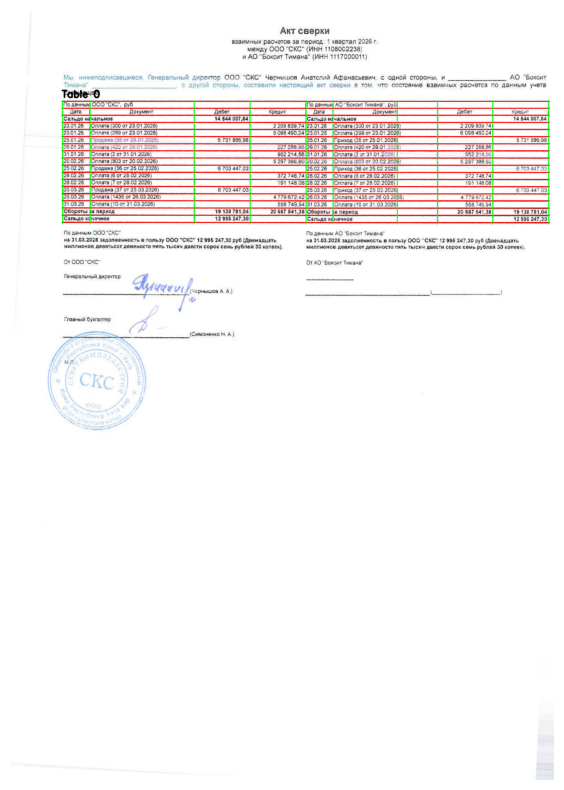

In [366]:
vis_grid = img.copy()

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, _ = detector._clean_mask_table(bbox, boxes, median_height)
    row_ys, col_xs = detector._build_grid(mask, median_height)
    print(f"Table {i}: row_ys={len(row_ys)}, col_xs={len(col_xs)}")
    x, y = int(bbox.x_min), int(bbox.y_min)
    crop_h, crop_w = int(bbox.height), int(bbox.width)

    for ly in row_ys:
        cv2.line(vis_grid, (x, y + ly), (x + crop_w, y + ly), (255, 0, 0), 2)
    for lx in col_xs:
        cv2.line(vis_grid, (x + lx, y), (x + lx, y + crop_h), (0, 255, 0), 2)
    cv2.putText(vis_grid, f"Table {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)


plt.figure(figsize=(10, 10))
plt.imshow(vis_grid)
plt.axis("off")
plt.show()

In [367]:
from PIL import Image, ImageDraw, ImageFont

from vision_core.detector.table_detector import (
    assign_blobs_to_cells,
    build_merged_regions,
    build_table_entity,
    detect_horizontal_borders,
    detect_vertical_borders,
    find_reocr_cells,
)

base = Image.fromarray(img.copy()).convert("RGBA")
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)
font = ImageFont.load_default(size=16)

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, _ = detector._clean_mask_table(bbox, boxes, median_height)
    row_ys, col_xs = detector._build_grid(mask, median_height)

    is_vborder = detect_vertical_borders(mask, row_ys, col_xs, tolerance=20, prominence_frac=0.2)
    is_hborder = detect_horizontal_borders(mask, row_ys, col_xs, tolerance=20, prominence_frac=0.2)

    n_rows = len(row_ys) - 1
    n_cols = len(col_xs) - 1

    labels = build_merged_regions(is_vborder, is_hborder, n_rows, n_cols, mode="all")
    table = build_table_entity(bbox, labels, row_ys, col_xs, f"{i}")
    cell_ocr = assign_blobs_to_cells(table.cells, ocr_results, min_overlap_ratio=0.1, confidence_threshold=0.4)
    reocr_cells_list = find_reocr_cells(table.cells, cell_ocr, min_containment_ratio=0.7, min_overlap_ratio=0.1)
    reocr_ids = {id(c) for c in reocr_cells_list}

    print(f"Table {i}: {len(reocr_cells_list)} / {len(table.cells)} cells flagged for re-OCR")

    for cell in table.cells:
        x0, y0, x1, y1 = cell.bbox.to_tuple()
        if id(cell) in reocr_ids:
            draw.rectangle([x0, y0, x1, y1], outline=(255, 0, 0, 255), fill=(255, 0, 0, 90), width=2)

    for b in boxes:
        draw.rectangle([b.x_min, b.y_min, b.x_max, b.y_max], outline=(0, 0, 255, 255), width=1)


vis_reocr = Image.alpha_composite(base, overlay).convert("RGB")
vis_reocr.show()


Table 0: 2 / 127 cells flagged for re-OCR


In [368]:
from PIL import Image, ImageDraw, ImageFont

list_tables = detector.detect_tables(img, ocr_results)

palette = [
    (255, 99, 71),
    (60, 179, 113),
    (65, 105, 225),
    (255, 165, 0),
    (147, 112, 219),
    (0, 206, 209),
    (220, 20, 60),
    (154, 205, 50),
]

base = Image.fromarray(img.copy()).convert("RGBA")
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)
font = ImageFont.load_default(size=16)

for table in list_tables:
    for idx, cell in enumerate(table.cells):
        x0, y0, x1, y1 = cell.bbox.to_tuple()
        r, g, b = palette[idx % len(palette)]
        draw.rectangle([x0, y0, x1, y1], outline=(0, 0, 0, 255), width=2, fill=(r, g, b, 90))
        draw.text((x0 + 3, y0 + 3), f"R{cell.row}:C{cell.col}", fill=(0, 0, 0, 255), font=font)

        text = (cell.value or "").replace("\n", " / ")
        print(f"R{cell.row}:C{cell.col} - {text}")

    draw.text((int(table.bbox.x_min), int(table.bbox.y_min) - 20), f"Table {table.id}", fill=(0, 0, 0, 255), font=font)

vis_final = Image.alpha_composite(base, overlay).convert("RGB")
vis_final.show()


R0:C0 - По данным ООО "СКС", руб
R0:C4 - По данным АО "Боксит Тимана". руб
R1:C0 - Дата
R1:C1 - Документ
R1:C2 - Дебет
R1:C3 - Кредит
R1:C4 - Дата
R1:C5 - Документ
R1:C7 - Дебет
R1:C8 - Кредит
R2:C0 - Сальдо начальное
R2:C2 - 14 544 007,64
R2:C3 - 
R2:C4 - Сальдо
R2:C5 - начальное
R2:C7 - 
R2:C8 - 14544 007,64
R3:C0 - 23.01.26
R3:C1 - Оплата(300 OT 23.01.2026
R3:C2 - 
R3:C3 - 2209 839,74
R3:C4 - 23.01.26
R3:C5 - Оплата (300 от 23.01.2026)
R3:C7 - 2 209 839.74
R3:C8 - 
R4:C0 - 23.01.26
R4:C1 - Оплата (299 от 23.01.2026)
R4:C2 - 
R4:C3 - 6098 490,24
R4:C4 - 23.01.26
R4:C5 - Оплата (299 от 23.01.2026)
R4:C7 - 6 098 490.24
R4:C8 - 
R5:C0 - 25.01.26
R5:C1 - Продажа (35 от 25.01.2026)
R5:C2 - 5 731 886,98
R5:C3 - 
R5:C4 - 25.01.26
R5:C5 - Приход (35 от 25.01.2026)
R5:C7 - 
R5:C8 - 5 731 886.98
R6:C0 - 29.01.26
R6:C1 - Оплата (420 от 29.01.2026)
R6:C2 - 
R6:C3 - 227288.86
R6:C4 - 29.01.26
R6:C5 - ОПлаТа (420 от 29.01.2026)
R6:C7 - 227 268,86
R6:C8 - 
R7:C0 - 31.0126
R7:C1 - ОnлаТа (2 от 31.01